# Расчетно Графическая Работа №1
## Вариант №1

> Численые методы анализа

> Выполнили: Егор Андреасян и Егор Захаров

> Группа: J3119



In [1]:
import random
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

SEED = 41
TEST_SIZE = 0.3

random.seed(SEED)
np.random.seed(SEED)

In [2]:
def plot_smart_boxplots(df: pd.DataFrame) -> list:
    sns.set_theme(style="whitegrid", palette="pastel")
    num_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [col for col in num_cols_raw if df[col].nunique() > 10]
    n_features = len(num_cols)
    if n_features == 0:
        return []
    if n_features <= 3:
        cols_in_row = n_features
    elif n_features == 4:
        cols_in_row = 2
    else:
        cols_in_row = 3 if n_features < 10 else 4
    rows = math.ceil(n_features / cols_in_row)
    fig, axes = plt.subplots(rows, cols_in_row,
                             figsize=(cols_in_row * 5, rows * 5),
                             squeeze=False)
    axes = axes.flatten()
    colors = sns.color_palette("pastel", n_colors=n_features)
    for i, col in enumerate(num_cols):
        ax = axes[i]
        sns.boxplot(
            y=df[col], 
            ax=ax, 
            color=colors[i],
            width=0.4,
            fliersize=3,
            linewidth=1.5
        )
        ax.set_title(f"{col}", fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel('')
    for j in range(n_features, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()
    return num_cols

# Смотрим данные

In [3]:
data = pd.read_csv('data/housing.csv', delimiter=';')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [4]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

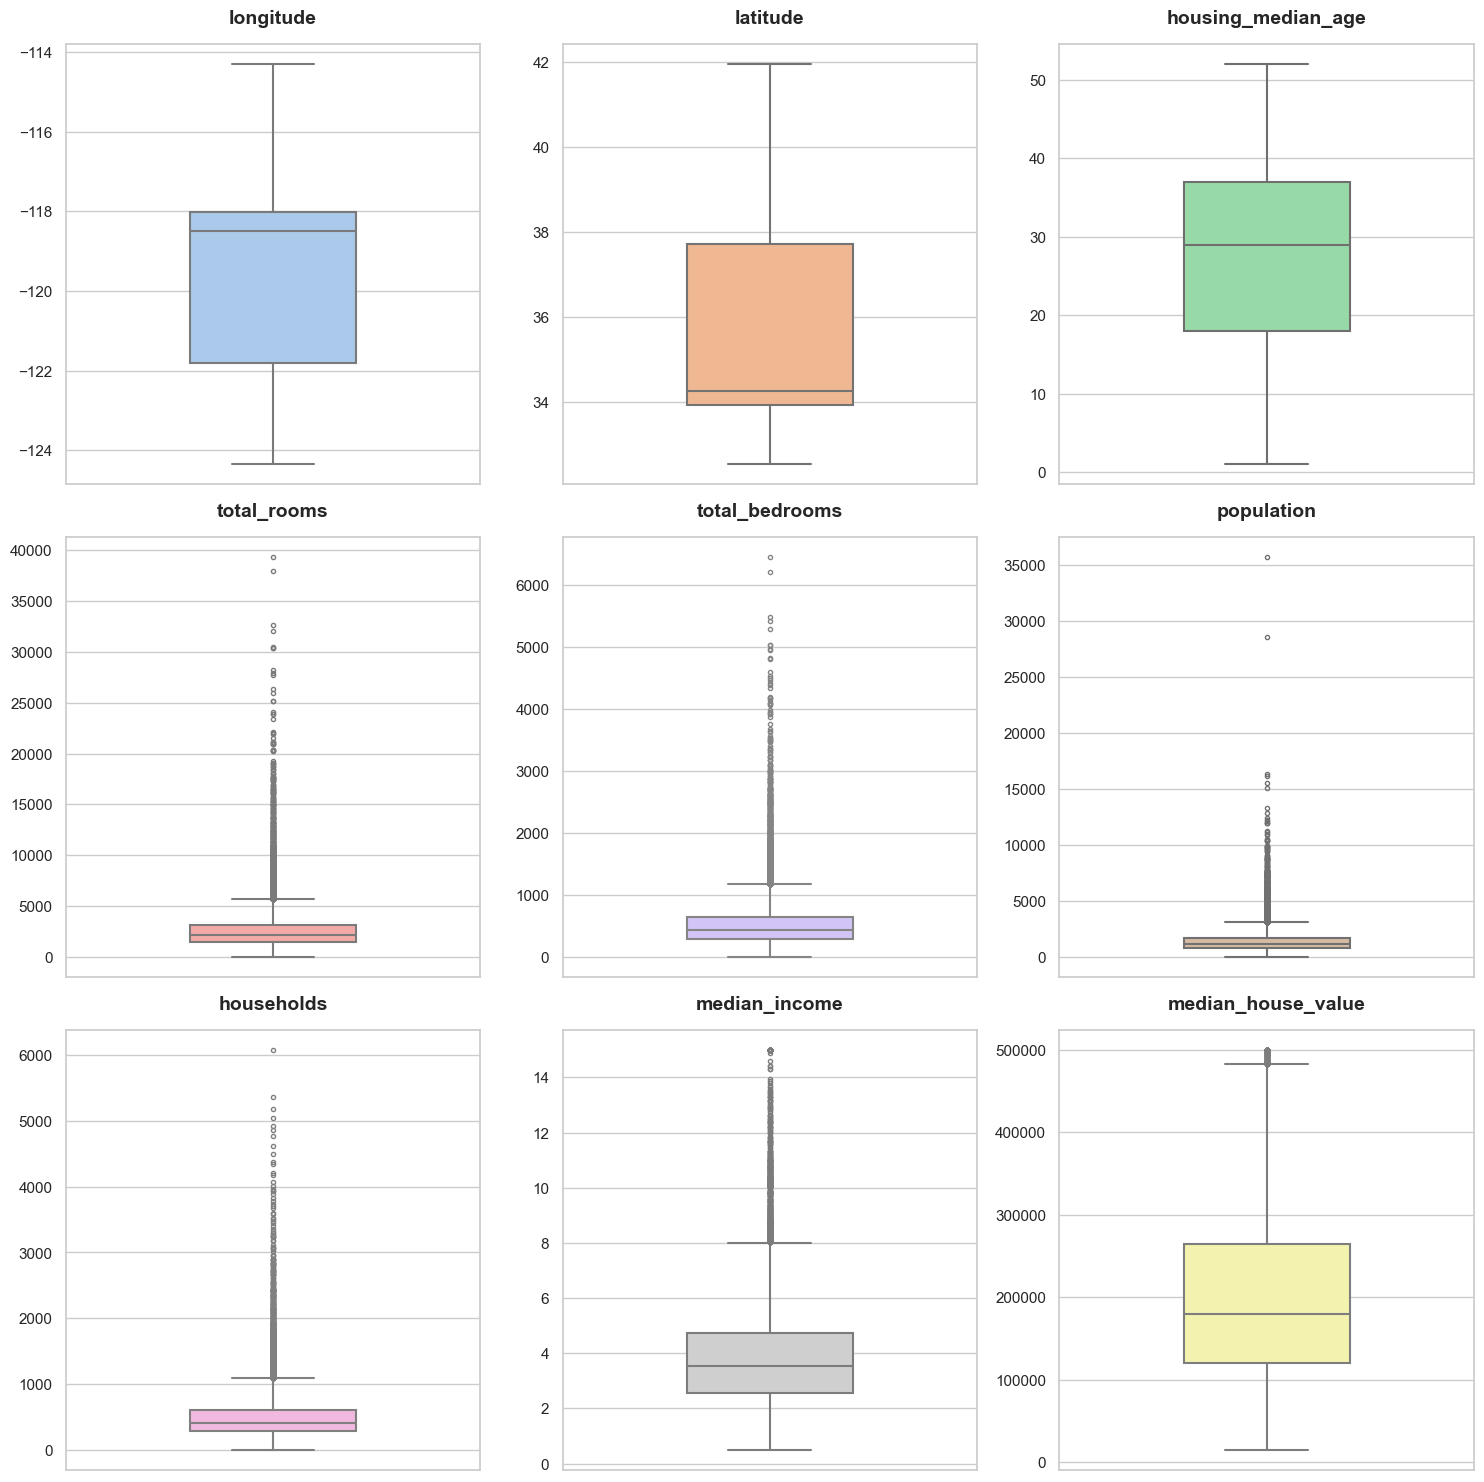

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [5]:
plot_smart_boxplots(data)

<Axes: >

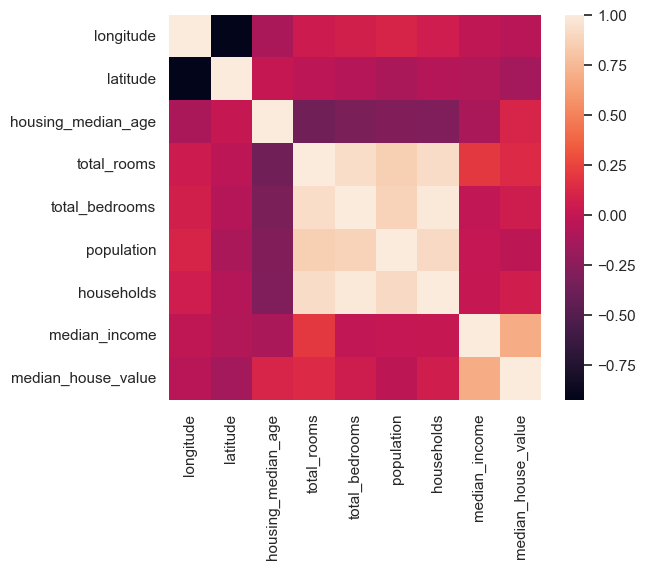

In [6]:
sns.set(rc={'figure.figsize': (6, 5)})
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix)

In [7]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
data.fillna(data.median(), inplace=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


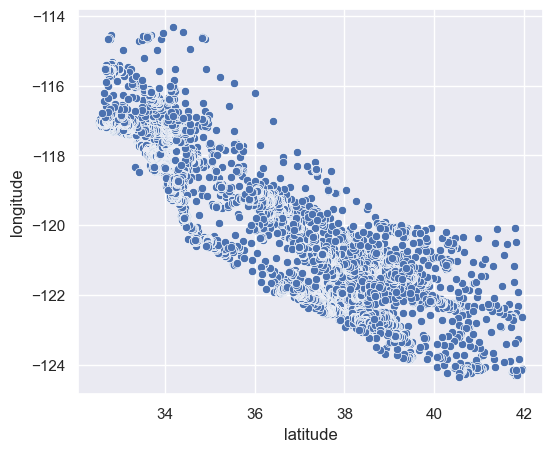

In [9]:
sns.scatterplot(data=data, x="latitude", y="longitude");

In [10]:
fig = px.scatter_mapbox(data, lat="latitude", lon="longitude",
                        mapbox_style="open-street-map", zoom=4)
fig.show()

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/895364316.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(data, lat="latitude", lon="longitude",


Данные с штата Калифорния в дальнейшем можно прикольные данные из этого взять

# Класс линейной регрессии и метрики

В ообще самая простая реалиация и вид линейной регрессии такой

$$
f(x) = Xw \\
X \text{ - матрица, наши данные где колонки - это признаки, а строки - просто следующие данные которые надо рассчитать} \\
 w \text{ - наши веса}
$$

В теории лабы написано что есть еще случайная ошиба, но в большинстве источников все ее сокращают и убирают из формулы [один из источникв](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/lecture-notes/lecture02-linregr.pdf)

Теперь связь со СЛАУ и МНК и тд, в чем вообще прикол, если пришлядеться то можно увидеть вообще такую картину

$$
Xw=y
$$

По факту наше СЛАУ ищим вектор весов $w$ чтобы получить наши таргеты $y$

Теперь причем тут МНК, если мы просто вычислим $w$ то какое-то отличие всеравно будет, и поэтому можно применить МНК, вычисляя веса так чтобы ошибка была минимальной

Ошибка выглядит так

$$
error = ||Xw - y|| ^ 2
$$

распишем

$$
error = ||Xw - y|| ^ 2 = (Xw - y)^T(Xw - y)= (w^TX^T - y^T)(Xw - y) = w^TX^TXw − w^TX^Ty − y^TXw + y^Ty \\
$$

$$
w^TX^Ty = (w^TX^Ty)^T = y^TXw
$$

$$
error = w^TX^TXw − 2w^TX^Ty + y^Ty
$$

Теперь посчитаем градиент

$$
\nabla error_w = 2X^TXw - 2X^Ty + 0
$$

$$
\nabla error_w = 2X^TXw - 2X^Ty
$$

Теперь нам нужен минимум ошибки, что делаем? очев

$$
\nabla error_w = 0
$$

$$
2X^TXw - 2X^Ty = 0
$$

$$
2X^TXw = 2X^Ty
$$

и тут мы получили СЛАУ, ищим мы $w$

$$
w = (X^TX)^{-1}X^Ty
$$

и по факту все, это как один из способов, либо можно искать веса через градиентный спуск

МНК это вообще наш критерий что он говорит, минимизируем квадрат ошибки и все 

In [11]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [12]:
def evaluate_models(models, X_test, y_test):
    results = []
    for name, model in models.items():
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        mse = mean_squared_error(y_test, preds)
        rmse = mse ** 0.5
        r2 = r2_score(y_test, preds)
        results.append({
            "Model": name,
            "MAE": f"{mae:.4f}",
            "RMSE": f"{rmse:.4f}",
            "MSE": f"{mse:.4f}",
            "R2": f"{r2:.4f}",
        })
    df = pd.DataFrame(results).set_index("Model")
    return df

In [13]:
class LinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y, fit_var: str='inv', iter: int=1024, learning_rate: float=0.01, eps: float= 1e-8, delta: float=1e-8):
        if fit_var == 'inv':
            self.w = np.linalg.inv(X.T @ X) @ X.T @ y
        elif fit_var == 'solve':
            self.w = np.linalg.solve(X.T @ X, X.T @ y)
        elif fit_var == 'lstsq':
            self.w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        elif fit_var == 'grad':
            self._fit_gradient_lin_reg(X, y, iter, learning_rate, eps, delta)
        else:
            raise ValueError(f"Unknown fit_var: {fit_var}")
    
    def _fit_gradient_lin_reg(self, X, y, iter, learning_rate, eps, delta):
        n = X.shape[0]
        self.w = np.zeros(X.shape[1])
        best_w = self.w.copy()
        best_error = np.inf
        for i in range(iter):
            pred = X @ self.w
            error = np.mean(np.abs(pred - y) ** 2)
            # grad = 2 * X.T @ X @ self.w - 2 * X.T @ y # спрашивал у клода почему тут все так плохо и почему-то тут 
            # не стабильный подсчет идет и поэтому надо подругому
            grad = (2 / n) * X.T @ (pred - y)
            self.w -= learning_rate * grad
            if error < best_error:
                best_error = error
                best_w = self.w.copy()
            if error < eps or np.linalg.norm(grad) < delta:
                break
        self.w = best_w

    def predict(self, X):
        return X @ self.w

# train test split

## Делим

In [14]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


In [15]:
X = data.drop(columns=["median_house_value"]).values
Y = data["median_house_value"].values

In [16]:
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=SEED
)

# Посмотр метрики без предобработок

In [17]:
lr_inv = LinearRegression()
lr_inv.fit(X_train, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [18]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),55160.7128,74883.2042,5607494278.1819,0.5792
Linear Regression (Solve),55160.7128,74883.2042,5607494278.1819,0.5792
Linear Regression (Lstsq),55160.7128,74883.2042,5607494278.1819,0.5792
Linear Regression (Grad),4132070584.6593,5278719998.4210,27864884821729521664.0000,-2091163879.5151


In [19]:
XTX = X_train.T @ X_train

cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 8745659.784579469


# Эксперименты с предобработкой

Нужно перебрать такие форматы параметров

| № | StandardScaler |  | Poly | MAE |  | Число обуч. |
|---|-----------------|--|------|-----|--|--------------|
|   | mean | std | degree | train | test | |
| 1 | False | False | 1 | ... | ... | ... |
| 2 | True  | False | 1 | ... | ... | ... |
| 3 | False | True  | 1 | ... | ... | ... |
| 4 | True  | True  | 1 | ... | ... | ... |
| 5 | True  | True  | 2 | ... | ... | ... |
| 6 | True  | True  | 3 | ... | ... | ... |

StandardScaler - обычное масштабирование данных
PolynomialFeatures - это уже прикольная штука, полимиальные комбинации, т е мы берем все наши фичи и делаем разные взаимодействия над каждой фичей либо над фичами в паре и тд, возводим в квадрат или переменожает друг с другом и тд зависит от degree

## StandardScaler без параметров(просто посмотрим)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

<Axes: >

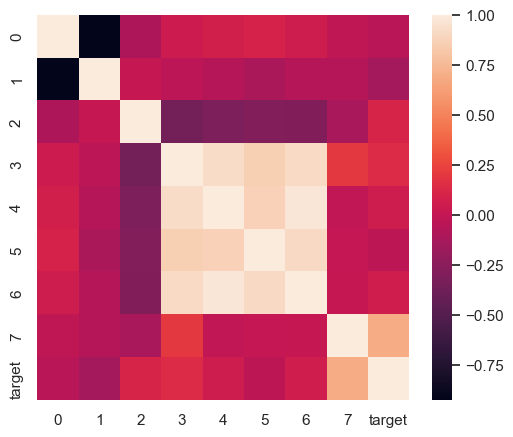

In [21]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [22]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [23]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_scaled, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),206143.1498,217396.5820,47261273865.5328,-2.5468
Linear Regression (Solve),206143.1498,217396.5820,47261273865.5328,-2.5468
Linear Regression (Lstsq),206143.1498,217396.5820,47261273865.5328,-2.5468
Linear Regression (Grad),205845.9848,220015.3008,48406732587.9625,-2.6328


In [24]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 180.07109852333164


## PolynomialFeatures с базовыми настройками

In [25]:
polym_f = PolynomialFeatures(include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

<Axes: >

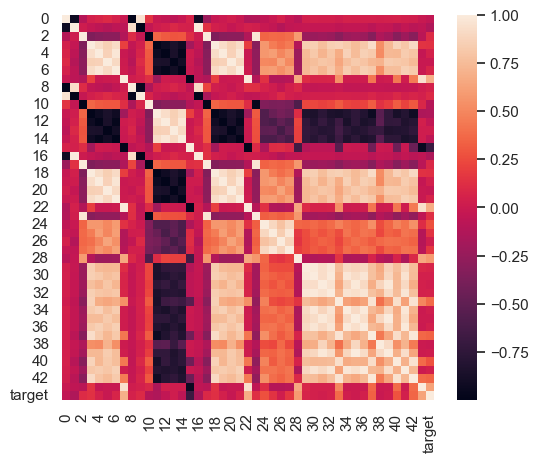

In [26]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_poly)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [27]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_poly, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_poly, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_poly, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_poly, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [28]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_poly, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),45616.8892,64819.2908,4201540463.2978,0.6847
Linear Regression (Solve),45616.8893,64819.2908,4201540463.3728,0.6847
Linear Regression (Lstsq),45616.8900,64819.2911,4201540503.2510,0.6847
Linear Regression (Grad),88604417006256368.0000,270417708111929056.0000,73125736860508466601892131622617088.0000,-5487835339606269708206080.0000


In [29]:
XTX = X_train_poly.T @ X_train_poly

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 2.1344500551199236e+19


# №1
| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 1 | False | False | 1 |

In [30]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=False, with_std=False)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

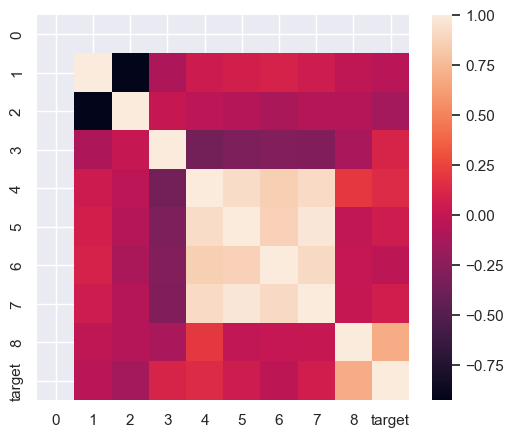

In [31]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [32]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [33]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_scaled, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),51213.5304,69908.1643,4887151428.9309,0.6332
Linear Regression (Solve),51213.5304,69908.1643,4887151428.9318,0.6332
Linear Regression (Lstsq),51213.5304,69908.1643,4887151428.9062,0.6332
Linear Regression (Grad),4132070999.4929,5278720323.1440,27864888249973067776.0000,-2091164136.7930


In [34]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 259815917560.25336


# №2
| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 2 | True  | False | 1 |

In [35]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=False)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

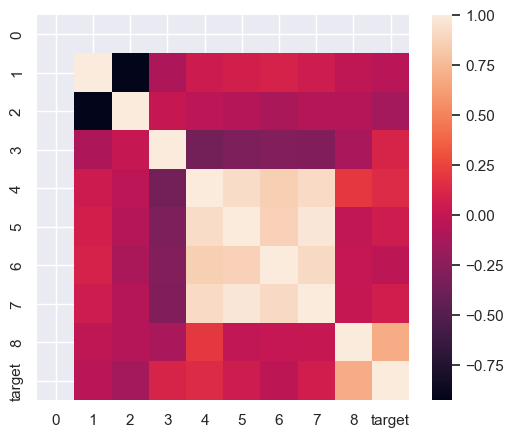

In [36]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [37]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [38]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_scaled, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),51213.5304,69908.1643,4887151428.9061,0.6332
Linear Regression (Solve),51213.5304,69908.1643,4887151428.9061,0.6332
Linear Regression (Lstsq),51213.5304,69908.1643,4887151428.9063,0.6332
Linear Regression (Grad),91267801.2465,147071623.7914,21630062524640932.0000,-1623260.8859


In [39]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 24499721.005351298


# №3

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 3 | False | True  | 1 |

In [40]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=False, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

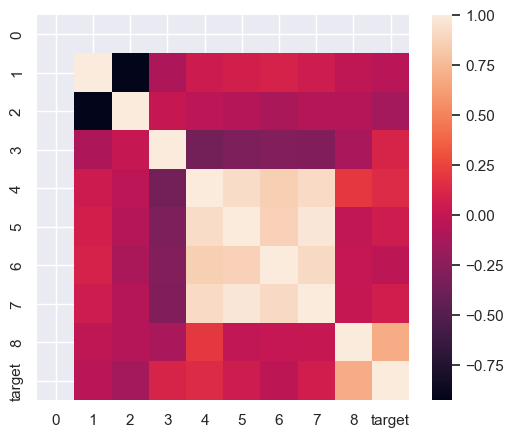

In [41]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [42]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_89771/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [43]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_scaled, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),51213.5304,69908.1643,4887151428.8969,0.6332
Linear Regression (Solve),51213.5304,69908.1643,4887151428.8963,0.6332
Linear Regression (Lstsq),51213.5304,69908.1643,4887151428.9061,0.6332
Linear Regression (Grad),1392413.0017,1397485.2041,1952964895754.7173,-145.5633


In [44]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 64380096.27540791


# №4

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 4 | True | True  | 1 |

In [45]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

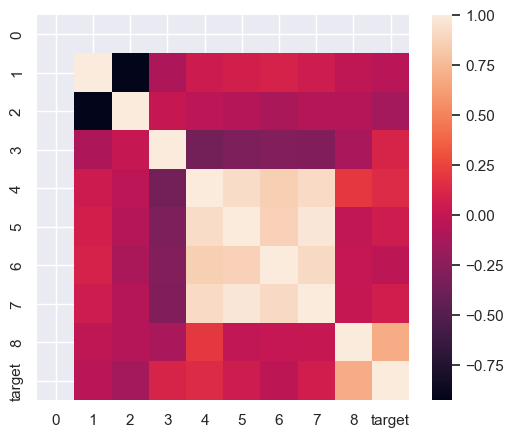

In [46]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [47]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [48]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_scaled, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),51213.5304,69908.1643,4887151428.9061,0.6332
Linear Regression (Solve),51213.5304,69908.1643,4887151428.9061,0.6332
Linear Regression (Lstsq),51213.5304,69908.1643,4887151428.9061,0.6332
Linear Regression (Grad),57095.6741,82049.8879,6732184112.3552,0.4948


In [49]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 180.07109852333102


# №5

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 5 | True | True  | 2 |

In [50]:
polym_f = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

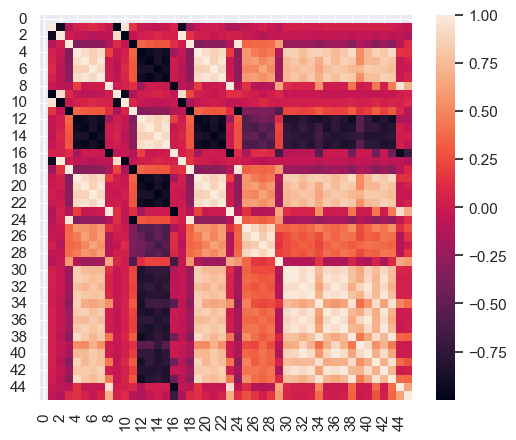

In [51]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [52]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [53]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_scaled, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),45512.3635,64806.3418,4199861940.3951,0.6848
Linear Regression (Solve),45512.3635,64806.3418,4199861940.3889,0.6848
Linear Regression (Lstsq),45512.3635,64806.3418,4199861940.3343,0.6848
Linear Regression (Grad),53085.1762,77425.6168,5994726136.4124,0.5501


In [54]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 52852716.51886541


# №6

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 6 | True | True  | 3 |

In [55]:
polym_f = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

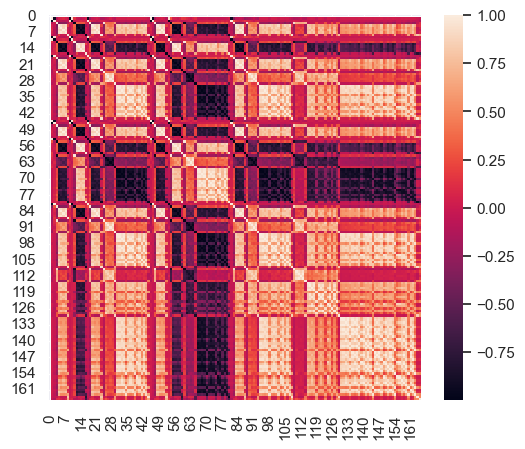

In [56]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [57]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [58]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_valid_scaled, Y_valid
)

,MAE,RMSE,MSE,R2
Model,,,,
Linear Regression (Inv),43085.5730,72026.8137,5187861893.9386,0.6107
Linear Regression (Solve),43085.5645,72026.8387,5187865491.3687,0.6107
Linear Regression (Lstsq),43085.5461,72026.6568,5187839284.8429,0.6107
Linear Regression (Grad),50949.4013,74076.7440,5487364004.1921,0.5882


In [59]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 6323926982886.163
